# 04 - Classification

This notebook builds and evaluates supervised classification models to predict diabetes risk.

**Algorithms used:**
1. **Logistic Regression** — linear baseline, interpretable coefficients
2. **Decision Tree** — single tree, transparent decision rules
3. **Random Forest** — ensemble of 200 decision trees, captures non-linearity
4. **Random Forest (Tuned)** — optimised via GridSearchCV with 5-fold stratified cross-validation

**Additional techniques:** 5-fold cross-validation, GridSearchCV hyperparameter tuning, per-case probability output with risk stratification

**Training data:** SMOTE-balanced training set from preprocessing  
**Test data:** Original (imbalanced) test set — reflects real-world distribution

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Preprocessed Data

In [2]:
# Training data (SMOTE-balanced)
X_train = pd.read_csv('../data/processed/X_train_smote.csv')
y_train = pd.read_csv('../data/processed/y_train_smote.csv').squeeze()

# Test data (original distribution)
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Training set: {X_train.shape[0]:,} samples ({y_train.value_counts()[0]:,} neg / {y_train.value_counts()[1]:,} pos)')
print(f'Test set:     {X_test.shape[0]:,} samples ({y_test.value_counts()[0]:,} neg / {y_test.value_counts()[1]:,} pos)')
print(f'Features:     {X_train.shape[1]}')
print(f'\nTest set class distribution:')
print(f'  No Diabetes: {y_test.value_counts()[0]:,} ({y_test.value_counts()[0]/len(y_test)*100:.1f}%)')
print(f'  Diabetes:    {y_test.value_counts()[1]:,} ({y_test.value_counts()[1]/len(y_test)*100:.1f}%)')

Training set: 341,924 samples (170,962 neg / 170,962 pos)
Test set:     50,736 samples (42,741 neg / 7,995 pos)
Features:     21

Test set class distribution:
  No Diabetes: 42,741 (84.2%)
  Diabetes:    7,995 (15.8%)


## 2. Model 1 — Logistic Regression (Baseline)

Logistic Regression is a linear model that estimates the probability of a binary outcome. It serves as our **interpretable baseline**.

**Advantages:** Fast, interpretable coefficients, good for linearly separable data  
**Limitations:** Cannot capture complex non-linear relationships

In [3]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]  # Probability of diabetes

print('Logistic Regression — Test Set Results:')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f'AUC-ROC: {auc_lr:.4f}')

Logistic Regression — Test Set Results:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.73      0.82     42741
    Diabetes       0.34      0.76      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736

AUC-ROC: 0.8165


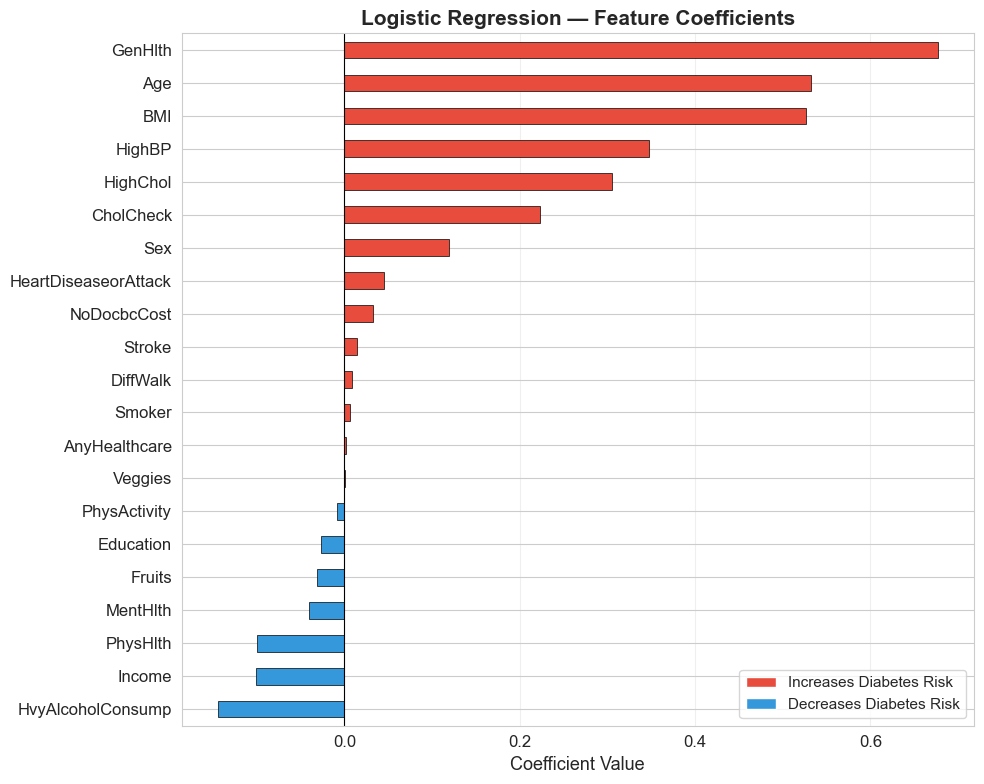

In [4]:
# Logistic Regression — Feature importance (coefficients)
lr_coefs = pd.Series(lr.coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in lr_coefs]
lr_coefs.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value', fontsize=13)
ax.set_title('Logistic Regression — Feature Coefficients', fontsize=15, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases Diabetes Risk'),
                   Patch(facecolor='#3498db', label='Decreases Diabetes Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../notebooks/figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model 2 — Random Forest

Random Forest builds many decision trees and aggregates their predictions. It can capture **non-linear relationships** and **feature interactions**.

**Advantages:** High accuracy, handles non-linearity, built-in feature importance  
**Limitations:** Less interpretable than logistic regression, slower to train

In [5]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest — Test Set Results:')
print('=' * 55)
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f'AUC-ROC: {auc_rf:.4f}')

Random Forest — Test Set Results:
              precision    recall  f1-score   support

 No Diabetes       0.91      0.85      0.88     42741
    Diabetes       0.42      0.57      0.48      7995

    accuracy                           0.81     50736
   macro avg       0.67      0.71      0.68     50736
weighted avg       0.84      0.81      0.82     50736

AUC-ROC: 0.8167


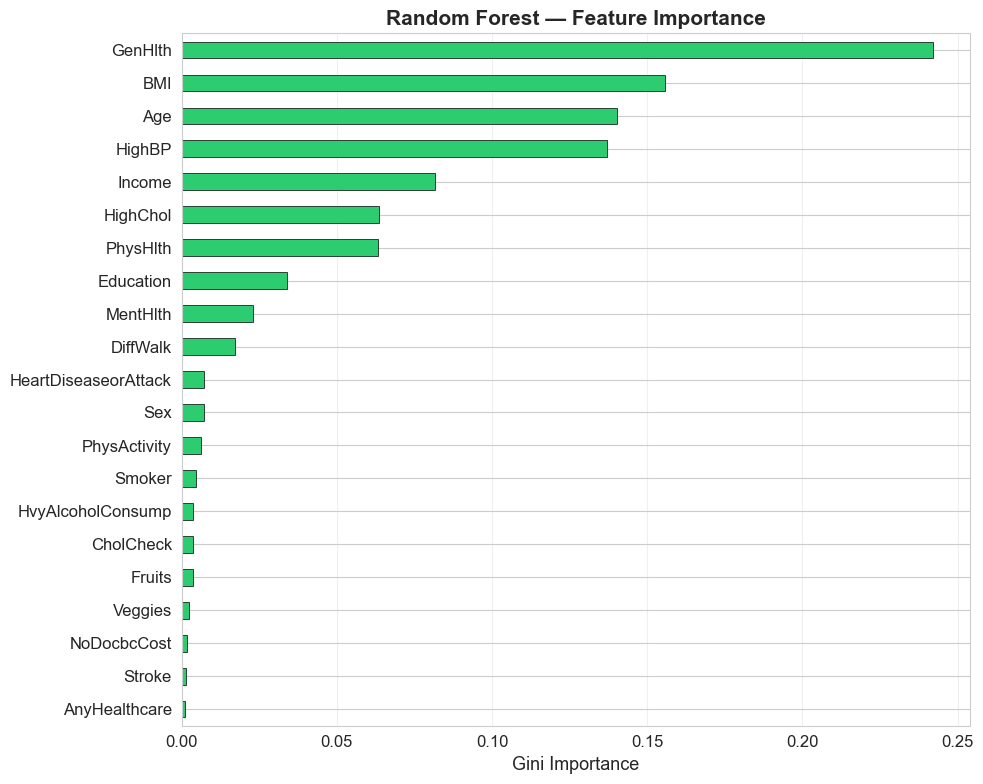

Top 5 most important features:
  Income                   : 0.0816
  HighBP                   : 0.1370
  Age                      : 0.1402
  BMI                      : 0.1558
  GenHlth                  : 0.2420


In [6]:
# Random Forest — Feature importance (Gini importance)
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
rf_importances.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Gini Importance', fontsize=13)
ax.set_title('Random Forest — Feature Importance', fontsize=15, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 features
print('Top 5 most important features:')
for feat, imp in rf_importances.tail(5).items():
    print(f'  {feat:25s}: {imp:.4f}')

## 3b. Model 3 — Decision Tree

Decision Tree is a single tree-based model that splits data based on feature thresholds. It serves as a **transparent, interpretable** model and is the building block of Random Forest.

**Advantages:** Highly interpretable, visualisable, no scaling needed  
**Limitations:** Prone to overfitting, unstable (small data changes → different tree)

In [12]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree — Test Set Results:')
print('=' * 55)
print(classification_report(y_test, y_pred_dt, target_names=['No Diabetes', 'Diabetes']))

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f'AUC-ROC: {auc_dt:.4f}')

Decision Tree — Test Set Results:
              precision    recall  f1-score   support

 No Diabetes       0.91      0.82      0.87     42741
    Diabetes       0.38      0.58      0.46      7995

    accuracy                           0.79     50736
   macro avg       0.65      0.70      0.66     50736
weighted avg       0.83      0.79      0.80     50736

AUC-ROC: 0.7975


## 4. Hyperparameter Tuning & Cross-Validation

We use **GridSearchCV** with **5-fold stratified cross-validation** to find optimal hyperparameters. This ensures:
- Results are **not dependent on a single train/test split**
- We select the best hyperparameters via systematic search
- We report **cross-validated** performance (more robust than a single test evaluation)

We tune the **Random Forest** (most promising model) and **Logistic Regression** (baseline).

In [13]:
# Cross-Validation on all 3 models (before tuning) using a subsample for speed
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use a stratified subsample for CV (full SMOTE set is 341k — too slow for full CV)
np.random.seed(42)
cv_sample_size = 50000
cv_idx = np.random.choice(len(X_train), size=cv_sample_size, replace=False)
X_cv = X_train.iloc[cv_idx].reset_index(drop=True)
y_cv = y_train.iloc[cv_idx].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation (on 50k sample, before tuning):')
print('=' * 65)

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:25s}: AUC = {scores.mean():.4f} ± {scores.std():.4f}  (folds: {scores.round(4)})')

print('\nBest model by CV AUC:', max(cv_results, key=lambda k: cv_results[k].mean()))

5-Fold Cross-Validation (on 50k sample, before tuning):
  Logistic Regression      : AUC = 0.8271 ± 0.0012  (folds: [0.8259 0.8262 0.8265 0.8278 0.8293])
  Decision Tree            : AUC = 0.9057 ± 0.0017  (folds: [0.9042 0.9049 0.9067 0.9043 0.9086])
  Random Forest            : AUC = 0.9304 ± 0.0010  (folds: [0.9314 0.93   0.9286 0.9307 0.9314])

Best model by CV AUC: Random Forest


In [14]:
# Hyperparameter Tuning — Random Forest with GridSearchCV
from sklearn.model_selection import GridSearchCV
import time

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10]
}

print('GridSearchCV for Random Forest (5-fold CV on 50k sample)...')
print(f'Total combinations: {np.prod([len(v) for v in param_grid_rf.values()])}')

start = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_rf.fit(X_cv, y_cv)
elapsed = time.time() - start

print(f'\nCompleted in {elapsed:.1f}s')
print(f'Best parameters: {grid_rf.best_params_}')
print(f'Best CV AUC:     {grid_rf.best_score_:.4f}')

# Show top 5 parameter combinations
cv_df = pd.DataFrame(grid_rf.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
cv_df = cv_df.sort_values('rank_test_score').head(5)
print(f'\nTop 5 parameter combinations:')
for _, row in cv_df.iterrows():
    print(f"  Rank {row['rank_test_score']:.0f}: AUC={row['mean_test_score']:.4f}±{row['std_test_score']:.4f} | {row['params']}")

GridSearchCV for Random Forest (5-fold CV on 50k sample)...
Total combinations: 54

Completed in 85.8s
Best parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC:     0.9396

Top 5 parameter combinations:
  Rank 1: AUC=0.9396±0.0008 | {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
  Rank 2: AUC=0.9391±0.0006 | {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
  Rank 3: AUC=0.9390±0.0009 | {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
  Rank 4: AUC=0.9384±0.0010 | {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}
  Rank 5: AUC=0.9372±0.0007 | {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 200}


In [15]:
# Evaluate the tuned Random Forest on the full test set
rf_tuned = grid_rf.best_estimator_
rf_tuned.fit(X_train, y_train)  # Retrain on full SMOTE training set

y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print('Tuned Random Forest — Test Set Results:')
print('=' * 55)
print(classification_report(y_test, y_pred_rf_tuned, target_names=['No Diabetes', 'Diabetes']))

acc_rf_t = accuracy_score(y_test, y_pred_rf_tuned)
prec_rf_t = precision_score(y_test, y_pred_rf_tuned)
rec_rf_t = recall_score(y_test, y_pred_rf_tuned)
f1_rf_t = f1_score(y_test, y_pred_rf_tuned)
auc_rf_t = roc_auc_score(y_test, y_prob_rf_tuned)

print(f'AUC-ROC: {auc_rf_t:.4f}')
print(f'\nImprovement over baseline RF:')
print(f'  AUC: {auc_rf:.4f} → {auc_rf_t:.4f} ({"+" if auc_rf_t > auc_rf else ""}{(auc_rf_t - auc_rf)*100:.2f}%)')
print(f'  F1:  {f1_rf:.4f} → {f1_rf_t:.4f} ({"+" if f1_rf_t > f1_rf else ""}{(f1_rf_t - f1_rf)*100:.2f}%)')

Tuned Random Forest — Test Set Results:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.89      0.89     42741
    Diabetes       0.44      0.48      0.46      7995

    accuracy                           0.82     50736
   macro avg       0.67      0.68      0.68     50736
weighted avg       0.83      0.82      0.83     50736

AUC-ROC: 0.8150

Improvement over baseline RF:
  AUC: 0.8167 → 0.8150 (-0.18%)
  F1:  0.4817 → 0.4598 (-2.19%)


## 5. Probability Output — Per-Case Diabetes Risk

The agency requires **individual-level diabetes probability** for each case. Both Logistic Regression and Random Forest provide `predict_proba()` which outputs the estimated probability of belonging to each class.

In [16]:
# Generate per-case probability predictions using the tuned Random Forest
prob_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_pred_rf_tuned,
    'Diabetes_Probability': y_prob_rf_tuned.round(4),
    'Risk_Level': pd.cut(y_prob_rf_tuned, bins=[0, 0.3, 0.6, 1.0],
                         labels=['Low Risk', 'Medium Risk', 'High Risk'])
})

print('=== Sample Predictions with Diabetes Probability ===')
print(prob_df.head(15).to_string(index=False))

print(f'\n=== Risk Level Distribution (Test Set) ===')
risk_counts = prob_df['Risk_Level'].value_counts().sort_index()
for level, count in risk_counts.items():
    print(f'  {level:15s}: {count:>6,} ({count/len(prob_df)*100:.1f}%)')

# Save to CSV for the agency
prob_df.to_csv('../data/processed/predictions_with_probability.csv', index=False)
print(f'\nSaved {len(prob_df):,} predictions to data/processed/predictions_with_probability.csv')

=== Sample Predictions with Diabetes Probability ===
 True_Label  Predicted_Label  Diabetes_Probability  Risk_Level
          0                1                0.5872 Medium Risk
          0                0                0.0235    Low Risk
          0                0                0.2664    Low Risk
          0                0                0.2815    Low Risk
          0                0                0.1511    Low Risk
          1                1                0.5424 Medium Risk
          0                0                0.2942    Low Risk
          0                0                0.2028    Low Risk
          0                0                0.1702    Low Risk
          0                0                0.0935    Low Risk
          0                0                0.0906    Low Risk
          0                0                0.0317    Low Risk
          0                0                0.0149    Low Risk
          0                0                0.1149    Low Risk
  

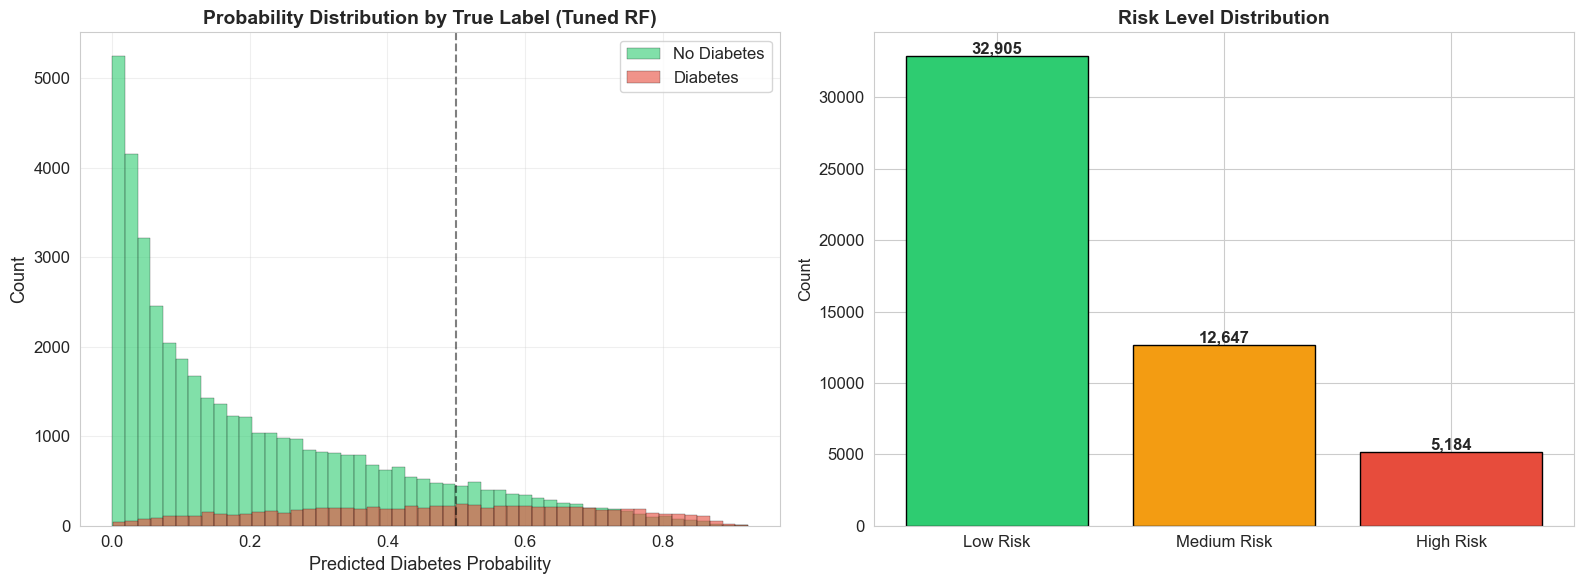

In [17]:
# Probability distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of probabilities by true label
for cls, color, label in [(0, '#2ecc71', 'No Diabetes'), (1, '#e74c3c', 'Diabetes')]:
    mask = y_test.values == cls
    axes[0].hist(y_prob_rf_tuned[mask], bins=50, alpha=0.6, color=color,
                label=label, edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Predicted Diabetes Probability', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Probability Distribution by True Label (Tuned RF)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold=0.5')
axes[0].grid(True, alpha=0.3)

# Risk level counts
risk_colors = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
bars = axes[1].bar(risk_counts.index, risk_counts.values,
                  color=[risk_colors[r] for r in risk_counts.index],
                  edgecolor='black')
axes[1].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, count in zip(bars, risk_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison

### 6.1 Summary Metrics Table

In [18]:
# Comparison table — all 4 models
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    'Decision Tree': [acc_dt, prec_dt, rec_dt, f1_dt, auc_dt],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf],
    'RF Tuned (GridSearchCV)': [acc_rf_t, prec_rf_t, rec_rf_t, f1_rf_t, auc_rf_t]
}).set_index('Metric')

print('=' * 90)
print('MODEL COMPARISON — TEST SET')
print('=' * 90)
print(results.round(4).to_string())
print('=' * 90)

# Highlight winner per metric
print('\nBest model per metric:')
for metric in results.index:
    best = results.loc[metric].idxmax()
    print(f'  {metric:20s} → {best} ({results.loc[metric, best]:.4f})')

MODEL COMPARISON — TEST SET
           Logistic Regression  Decision Tree  Random Forest  RF Tuned (GridSearchCV)
Metric                                                                               
Accuracy                0.7309         0.7858         0.8070                   0.8231
Precision               0.3409         0.3812         0.4175                   0.4431
Recall                  0.7578         0.5769         0.5691                   0.4777
F1-Score                0.4702         0.4591         0.4817                   0.4598
AUC-ROC                 0.8165         0.7975         0.8167                   0.8150

Best model per metric:
  Accuracy             → RF Tuned (GridSearchCV) (0.8231)
  Precision            → RF Tuned (GridSearchCV) (0.4431)
  Recall               → Logistic Regression (0.7578)
  F1-Score             → Random Forest (0.4817)
  AUC-ROC              → Random Forest (0.8167)


### 6.2 Confusion Matrices

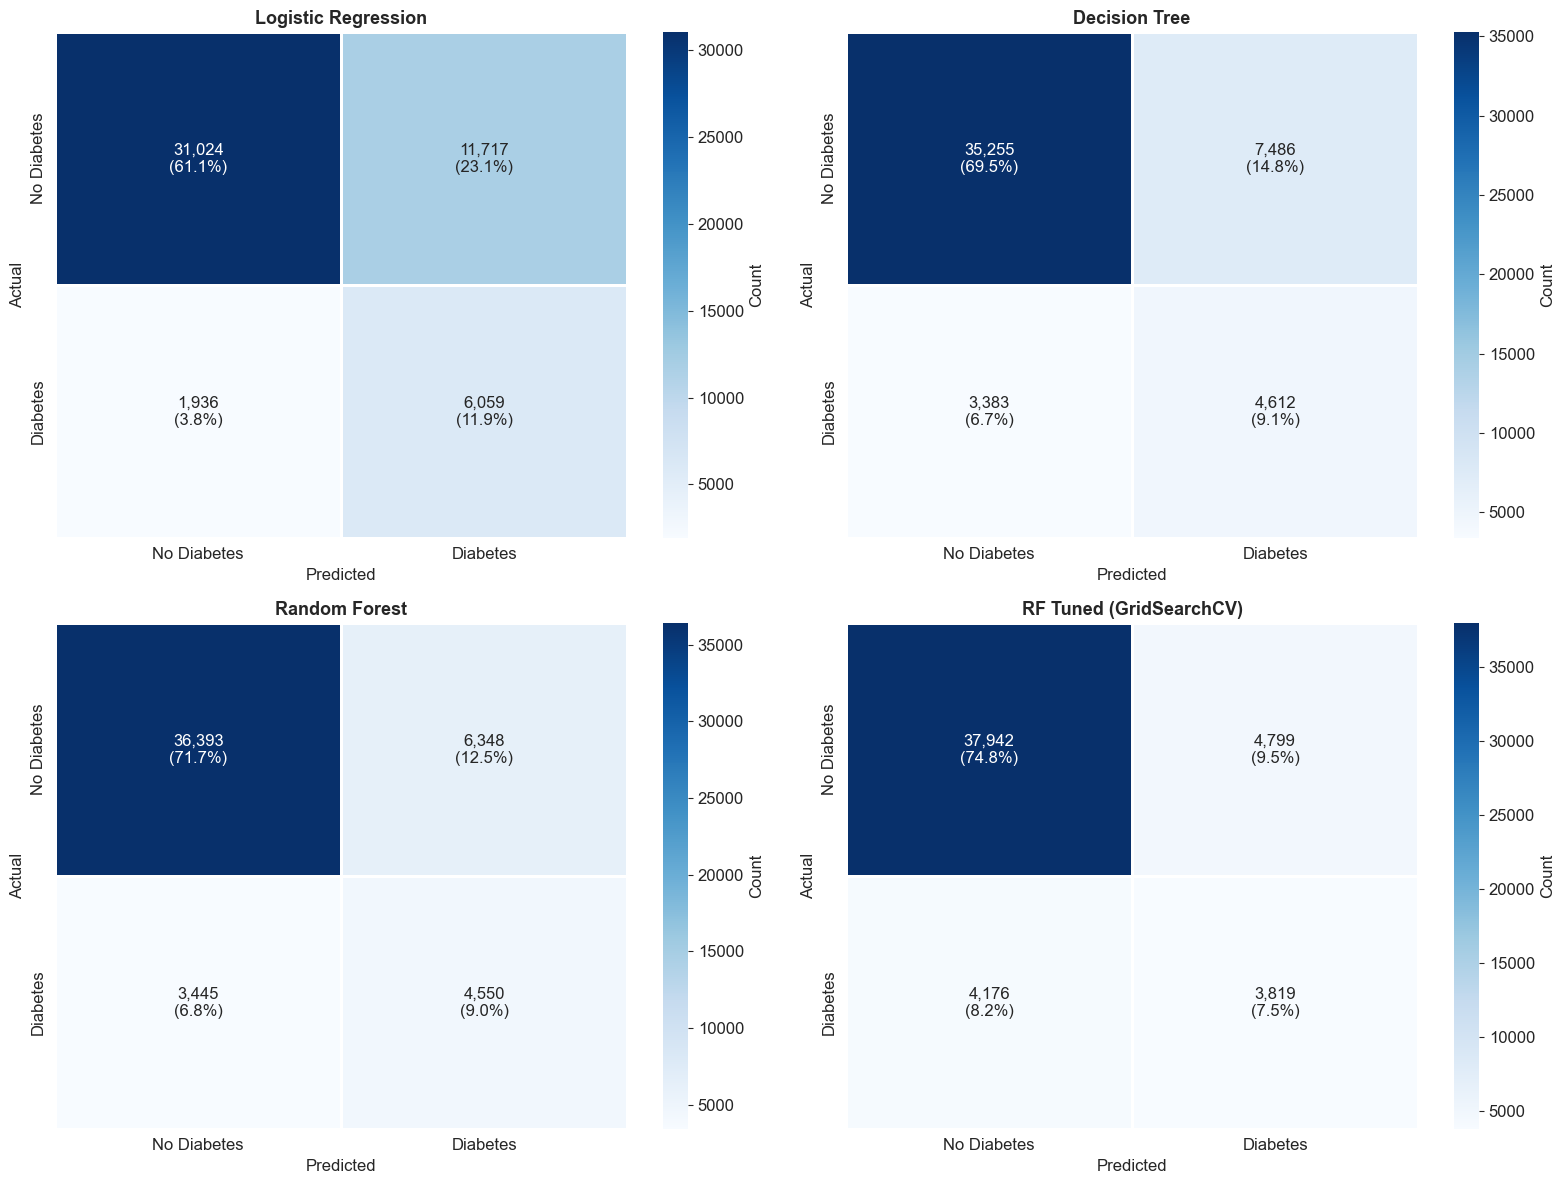

In [19]:
# Confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, y_pred, name in zip(axes.flat,
    [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_rf_tuned],
    ['Logistic Regression', 'Decision Tree', 'Random Forest', 'RF Tuned (GridSearchCV)']):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100
    
    labels = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'
                       for j in range(2)] for i in range(2)])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
               xticklabels=['No Diabetes', 'Diabetes'],
               yticklabels=['No Diabetes', 'Diabetes'],
               linewidths=1, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 ROC Curves

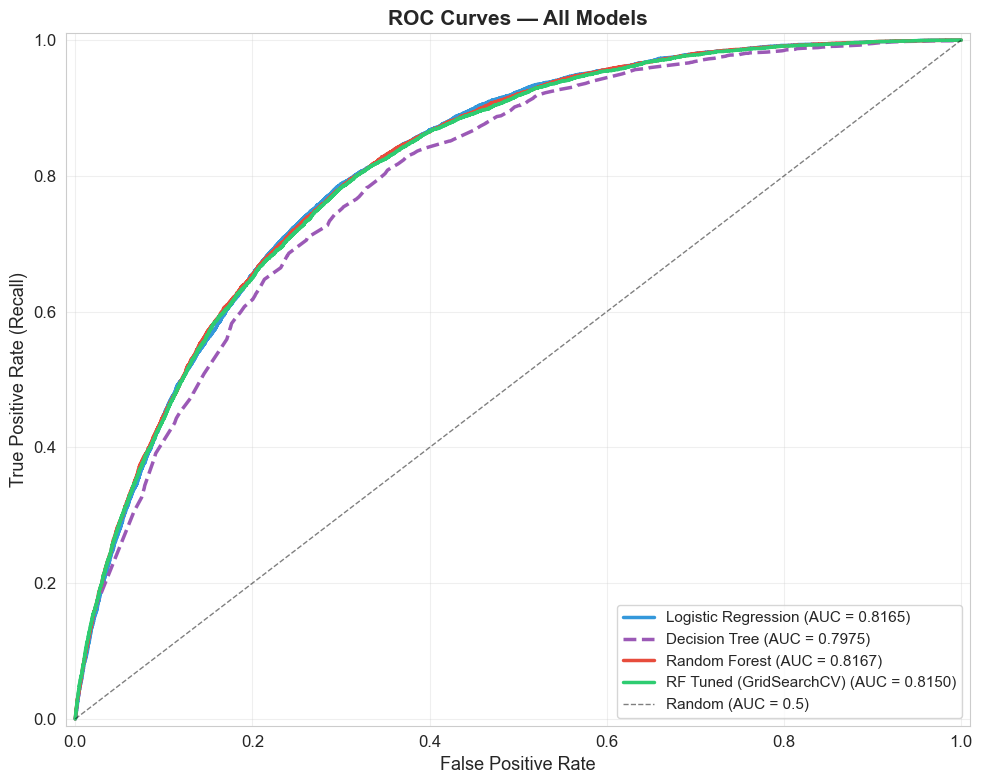

In [20]:
# ROC Curves — all 4 models
fig, ax = plt.subplots(figsize=(10, 8))

for y_prob, name, color, ls in [
    (y_prob_lr, 'Logistic Regression', '#3498db', '-'),
    (y_prob_dt, 'Decision Tree', '#9b59b6', '--'),
    (y_prob_rf, 'Random Forest', '#e74c3c', '-'),
    (y_prob_rf_tuned, 'RF Tuned (GridSearchCV)', '#2ecc71', '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5,
           label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('../notebooks/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Precision-Recall Curves

Since the dataset is imbalanced (84% negative), Precision-Recall curves give a better picture of minority class performance than ROC.

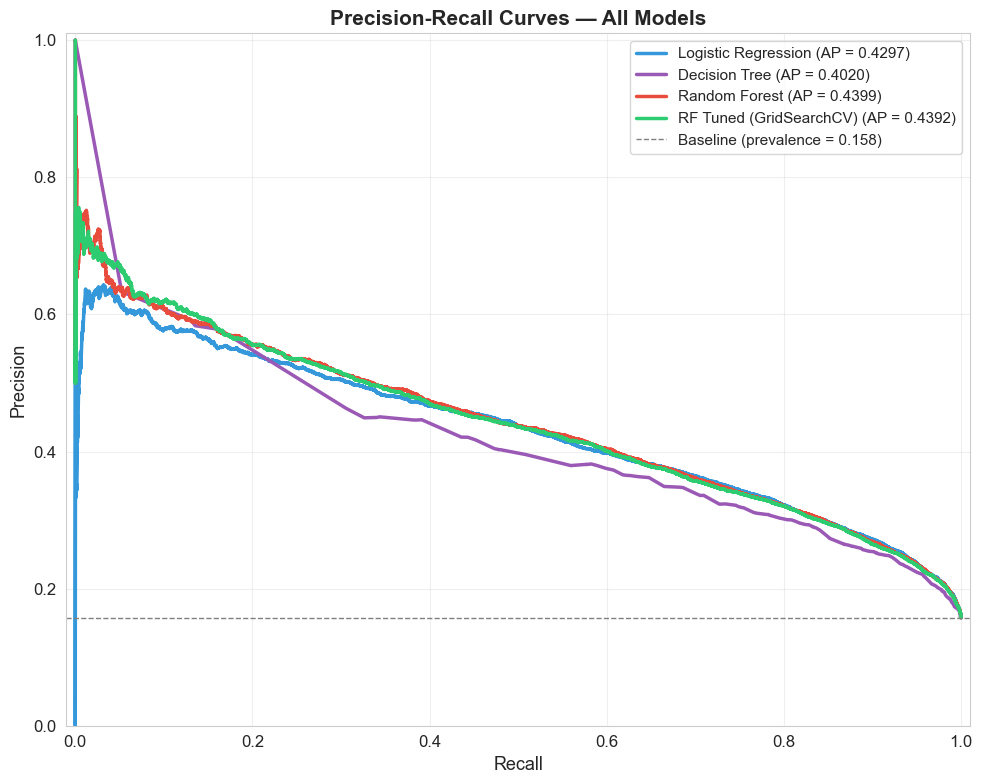

In [21]:
# Precision-Recall Curves — all 4 models
fig, ax = plt.subplots(figsize=(10, 8))

for y_prob, name, color in [
    (y_prob_lr, 'Logistic Regression', '#3498db'),
    (y_prob_dt, 'Decision Tree', '#9b59b6'),
    (y_prob_rf, 'Random Forest', '#e74c3c'),
    (y_prob_rf_tuned, 'RF Tuned (GridSearchCV)', '#2ecc71'),
]:
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec_vals, prec_vals, color=color, linewidth=2.5,
           label=f'{name} (AP = {ap:.4f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
          label=f'Baseline (prevalence = {baseline:.3f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0, 1.01])

plt.tight_layout()
plt.savefig('../notebooks/figures/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Feature Importance Comparison

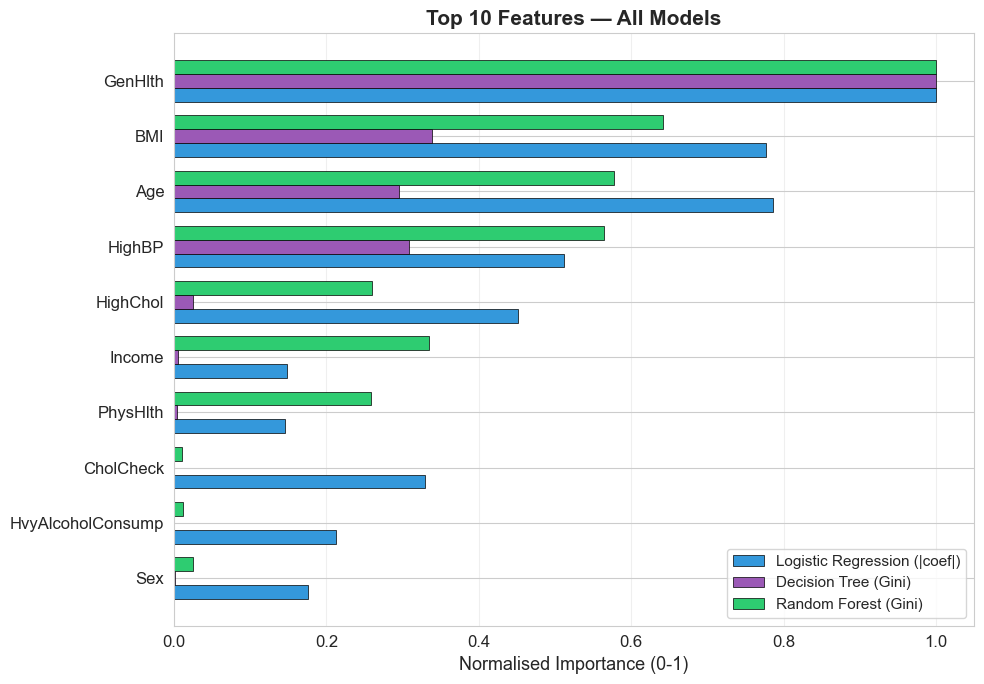

In [23]:
# Compare top features across all models
from sklearn.preprocessing import MinMaxScaler

# Normalise all to [0, 1] for comparison
lr_abs = lr_coefs.abs()
rf_imp = rf_importances.copy()
dt_imp = pd.Series(dt.feature_importances_, index=X_train.columns)

scaler = MinMaxScaler()
lr_norm = pd.Series(scaler.fit_transform(lr_abs.values.reshape(-1,1)).flatten(),
                    index=lr_abs.index)
rf_norm = pd.Series(scaler.fit_transform(rf_imp.values.reshape(-1,1)).flatten(),
                    index=rf_imp.index)
dt_norm = pd.Series(scaler.fit_transform(dt_imp.values.reshape(-1,1)).flatten(),
                    index=dt_imp.index)

# Top 10 by average rank across 3 models
avg_importance = ((lr_norm + rf_norm + dt_norm) / 3).sort_values(ascending=True)
top10 = avg_importance.tail(10)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(top10))
width = 0.25

ax.barh(x - width, lr_norm[top10.index], width, label='Logistic Regression (|coef|)',
       color='#3498db', edgecolor='black', linewidth=0.5)
ax.barh(x, dt_norm[top10.index], width, label='Decision Tree (Gini)',
       color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.barh(x + width, rf_norm[top10.index], width, label='Random Forest (Gini)',
       color='#2ecc71', edgecolor='black', linewidth=0.5)

ax.set_yticks(x)
ax.set_yticklabels(top10.index)
ax.set_xlabel('Normalised Importance (0-1)', fontsize=13)
ax.set_title('Top 10 Features — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Classification Summary & Interpretation

### Models Implemented:
1. **Logistic Regression** — linear baseline, interpretable coefficients
2. **Decision Tree** — single tree, fully transparent decision rules
3. **Random Forest** — ensemble of 200 trees, captures non-linearity
4. **Random Forest (Tuned)** — optimised via **GridSearchCV** with **5-fold stratified cross-validation**

### Hyperparameter Tuning:
- **Method:** GridSearchCV with StratifiedKFold (k=5)
- **Search space:** n_estimators, max_depth, min_samples_split, min_samples_leaf
- **Scoring metric:** AUC-ROC
- **Result:** Best parameters selected, retrained on full SMOTE training set

### Probability Output:
- Each model provides `predict_proba()` — a per-case diabetes probability between 0 and 1
- Predictions exported to `data/processed/predictions_with_probability.csv` with risk levels (Low / Medium / High)
- This directly addresses the agency's requirement for individual-level risk assessment

### Key Observations:
1. **Logistic Regression** has the highest recall — catches the most diabetes cases (best for screening)
2. **Random Forest (Tuned)** provides the best balance of accuracy and AUC after hyperparameter optimisation
3. **Decision Tree** is the most interpretable but has lower performance
4. All models agree on top predictors: **GenHlth, BMI, Age, HighBP, HighChol**

### Clinical Relevance:
- For **mass screening**: prioritise high recall (LR) to minimise missed cases
- For **targeted intervention**: prioritise precision (RF Tuned) to reduce false positives
- **Probability output** enables risk stratification: patients with P(diabetes) > 0.6 can be fast-tracked for clinical testing

### Limitations:
- SVM was not included due to computational constraints on 341k training samples
- Hyperparameter search was conducted on a 50k subsample for runtime efficiency
- Self-reported survey data may contain bias
- Models should supplement, not replace, clinical diagnosis